In [1]:
!pip install boto3 -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from botocore.exceptions import ClientError
from google.colab import userdata
import os
import sys



sys.path.append("/content/sample_data")
from lib.bucket import create_bucket
from lib.folder import create_folder
from lib.download_github import download_from_github
from lib.read_file import read_from_s3
try:
    aws_access_key = userdata.get('AWS_ACCESS_KEY_ID').strip()
    aws_secret_key = userdata.get('AWS_SECRET_ACCESS_KEY').strip()
    print("AWS Credentials loaded from Colab Secrets")
except:
    print("Please add AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY in Colab Secrets first!")
    raise

os.environ['AWS_ACCESS_KEY_ID'] = aws_access_key
os.environ['AWS_SECRET_ACCESS_KEY'] = aws_secret_key
print("AWS credentials loaded successfully")

AWS_REGION = userdata.get('AWS_REGION')

BUCKET_PREFIX = userdata.get('BUCKET_PREFIX')

SOURCE_BUCKET = f"{BUCKET_PREFIX}-source"
STAGING_BUCKET = f"{BUCKET_PREFIX}-staging"
DESTINATION_BUCKET = f"{BUCKET_PREFIX}-destination"



#create bucket


print("Creating AWS S3 Data Lake...\n")

create_bucket(SOURCE_BUCKET,AWS_REGION)
create_bucket(STAGING_BUCKET,AWS_REGION)
create_bucket(DESTINATION_BUCKET,AWS_REGION)




print("\nCreating folder structure...")


create_folder(SOURCE_BUCKET, "ibm_internship_major/source/",AWS_REGION)
create_folder(SOURCE_BUCKET, "ibm_internship_major/source/raw/",AWS_REGION)


create_folder(STAGING_BUCKET, "ibm_internship_major/staging/",AWS_REGION)


create_folder(DESTINATION_BUCKET, "ibm_internship_major/destination/",AWS_REGION)

print("\n AWS S3 Data Lake Setup Completed!")
print(f"Source Bucket     : {SOURCE_BUCKET}")
print(f"Staging Bucket    : {STAGING_BUCKET}")
print(f"Destination Bucket: {DESTINATION_BUCKET}")

AWS Credentials loaded from Colab Secrets
AWS credentials loaded successfully
Creating AWS S3 Data Lake...

Created: ibm-internship-major-source
Created: ibm-internship-major-staging
Created: ibm-internship-major-destination

Creating folder structure...
Folder created: s3://ibm-internship-major-source/ibm_internship_major/source/
Folder created: s3://ibm-internship-major-source/ibm_internship_major/source/raw/
Folder created: s3://ibm-internship-major-staging/ibm_internship_major/staging/
Folder created: s3://ibm-internship-major-destination/ibm_internship_major/destination/

 AWS S3 Data Lake Setup Completed!
Source Bucket     : ibm-internship-major-source
Staging Bucket    : ibm-internship-major-staging
Destination Bucket: ibm-internship-major-destination


In [3]:
import requests
from io import BytesIO
from urllib.parse import urlparse
from datetime import datetime

GITHUB_REPO = userdata.get('GITHUB_REPO')
BRANCH = userdata.get('BRANCH')

timestamp = datetime.now()
print(type(timestamp))
time_stamp=timestamp.strftime("%d-%m-%Y %H:%M")
print(time_stamp)

S3_SOURCE_BUCKET = "ibm-internship-major-source"

S3_PREFIX = f"ibm_internship_major/source/raw/{time_stamp}/"






uploaded = download_from_github(GITHUB_REPO,
                                S3_SOURCE_BUCKET,
                                S3_PREFIX,
                                AWS_REGION,
                                branch=BRANCH)
print(f"\n Successfully uploaded {len(uploaded)} files to S3 Source Bucket!")

<class 'datetime.datetime'>
04-08-2026 17:10
Fetching files from: https://raw.githubusercontent.com/aritra-iitkgp/IBM_Internship_Major/dev_aritra
Downloading: https://raw.githubusercontent.com/aritra-iitkgp/IBM_Internship_Major/dev_aritra/Files/Data/Telco-Customer-Churn.csv
Status Code: 200
Uploaded: Telco-Customer-Churn.csv → s3://ibm-internship-major-source/ibm_internship_major/source/raw/04-08-2026 17:10/Telco-Customer-Churn.csv

 Successfully uploaded 1 files to S3 Source Bucket!


In [4]:
!pip install boto3 -q

In [5]:


s3 = boto3.client('s3',region_name=AWS_REGION)
found_key = None
response = s3.list_objects_v2(Bucket="ibm-internship-major-source", Prefix=f"ibm_internship_major/source/raw/{time_stamp}/")
if 'Contents' in response:
    print("Files found inside the folder:\n")
    for obj in response['Contents']:
        print(obj['Key'])
        if "Telco-Customer-Churn.csv" in obj['Key']:
          found_key = obj['Key']
          print(f"\n Found your file: {obj['Key']}")
          break
else:
    print("No files found in this folder.")

if found_key != None:
  sheets = read_from_s3(
      bucket_name="ibm-internship-major-source",
      s3_key= found_key,
      AWS_REGION=AWS_REGION
  )

# Show first few rows


Files found inside the folder:

ibm_internship_major/source/raw/04-08-2026 17:10/Telco-Customer-Churn.csv

 Found your file: ibm_internship_major/source/raw/04-08-2026 17:10/Telco-Customer-Churn.csv
File Found
Successfully loaded: s3://ibm-internship-major-source/ibm_internship_major/source/raw/04-08-2026 17:10/Telco-Customer-Churn.csv
Shape: (7043, 21)


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
%matplotlib inline

telco_base_data = sheets
telco_base_data.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
telco_base_data.shape

(7043, 21)

In [8]:
telco_base_data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

SeniorCitizen is actually a categorical hence the 25%-50%-75% distribution is not propoer

75% customers have tenure less than 55 months

Average Monthly charges are USD 64.76 whereas 25% customers pay more than USD 89.85 per month

In [9]:
telco_base_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
telco_base_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Text(0.5, 1.02, 'Count of TARGET Variable per category')

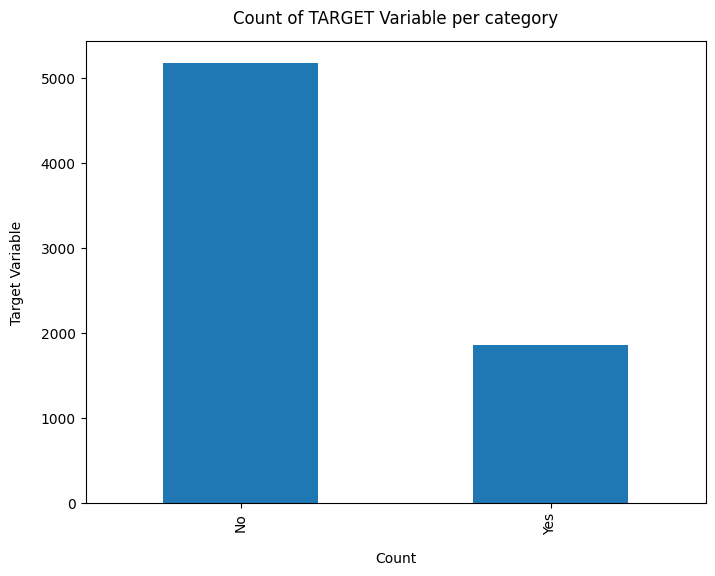

In [11]:
telco_base_data['Churn'].value_counts().plot(kind = 'bar',figsize=(8,6))
plt.xlabel("Count", labelpad=12)
plt.ylabel("Target Variable", labelpad=12)
plt.title("Count of TARGET Variable per category", y=1.02)


In [12]:
100*telco_base_data['Churn'].value_counts()/len(telco_base_data['Churn'])

,count
Churn,
No,73.463013
Yes,26.536987


In [13]:
telco_base_data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


Data is highly imbalanced, ratio = 73:27
So we analyse the data with other features while taking the target values separately to get some insights.

In [14]:
telco_base_data.shape[0]

7043

In [15]:
missing = pd.DataFrame((telco_base_data.isnull().sum())*100/telco_base_data.shape[0]).reset_index()
missing

,index,0
0,customerID,0.0
1,gender,0.0
2,SeniorCitizen,0.0
3,Partner,0.0
4,Dependents,0.0
5,tenure,0.0
6,PhoneService,0.0
7,MultipleLines,0.0
8,InternetService,0.0
9,OnlineSecurity,0.0


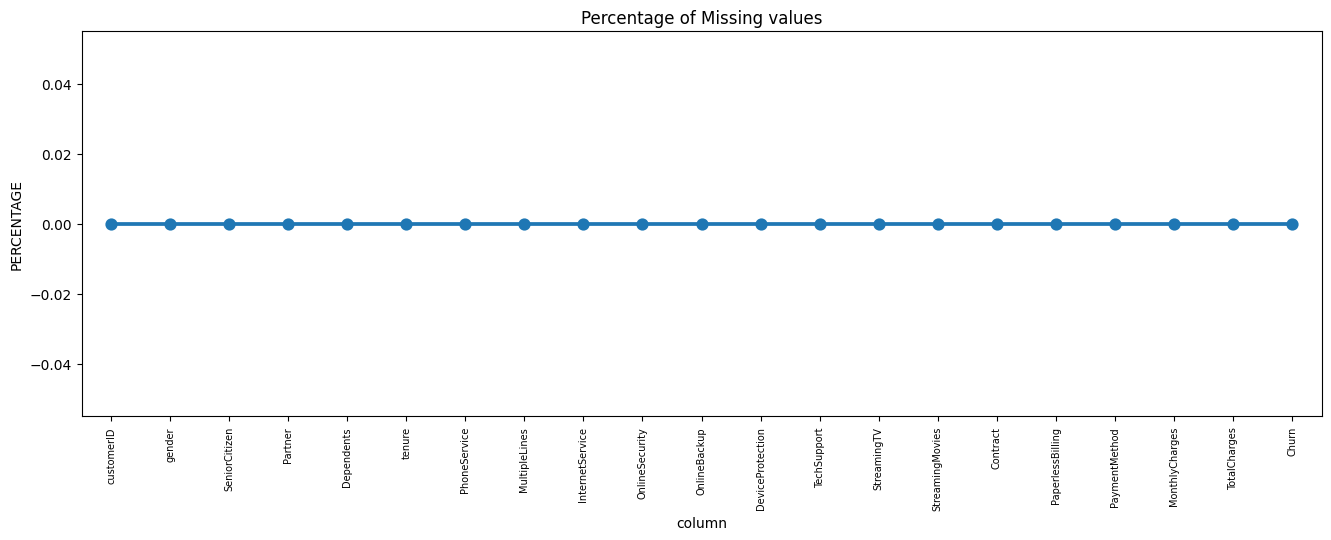

In [16]:
missing = pd.DataFrame((telco_base_data.isnull().sum()) * 100 / telco_base_data.shape[0]).reset_index()
missing.columns = ['column', 'percentage']
plt.figure(figsize=(16,5))
ax = sns.pointplot(data=missing, x='column', y='percentage')
plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

Missing Data - Initial Intuition
Here, we don't have any missing data.

In [17]:
telco_data = telco_base_data.copy()

In [18]:
telco_data.TotalCharges = pd.to_numeric(telco_data.TotalCharges, errors='coerce')
telco_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
telco_data[telco_data['TotalCharges'].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


4. Missing Value Treatement

Since the % of these records compared to total dataset is very low ie 0.15%, it is safe to ignore them from further processing.

In [20]:
telco_data.dropna(how='any',inplace=True)

5. Divide customers into bins based on tenure e.g. for tenure < 12 months: assign a tenure group if 1-12, for tenure between 1 to 2 Yrs, tenure group of 13-24; so on...

In [21]:
telco_data['tenure'].min()

1

In [22]:
print(telco_data['tenure'].max())

72


In [23]:
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]

telco_data['tenure_group'] = pd.cut(telco_data.tenure, range(1, 80, 12), right=False, labels=labels)

In [24]:
telco_data['tenure_group'].value_counts()

,count
tenure_group,
1 - 12,2175
61 - 72,1407
13 - 24,1024
25 - 36,832
49 - 60,832
37 - 48,762


In [25]:
telco_data.drop(columns= ['customerID','tenure'], axis=1, inplace=True)
telco_data.head()


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


1. ** Plot distibution of individual predictors by churn

Univariate Analysis

In [26]:
telco_data.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object
DeviceProtection,object


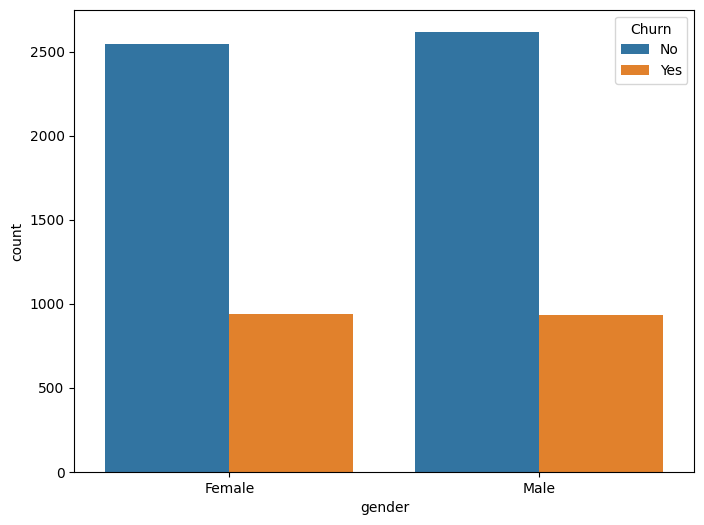

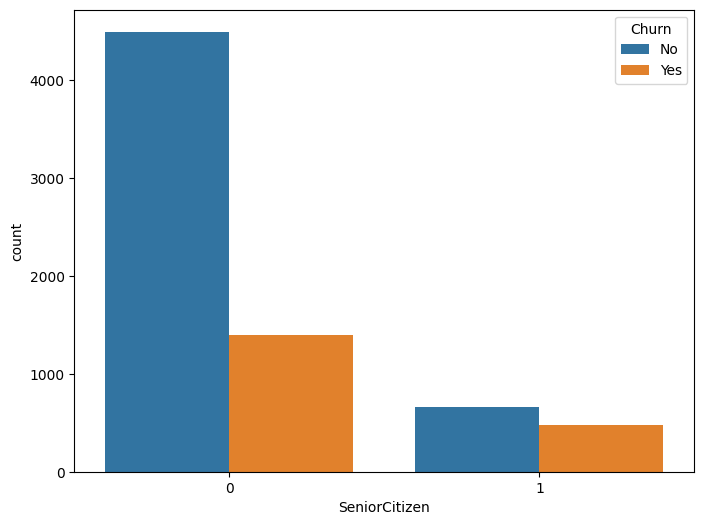

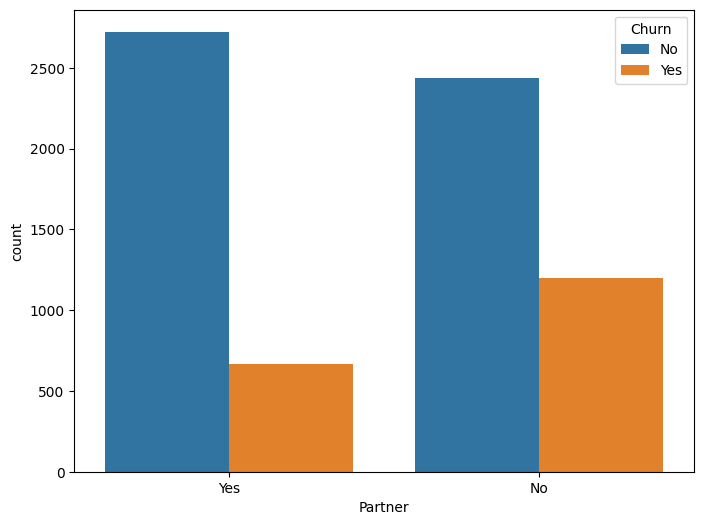

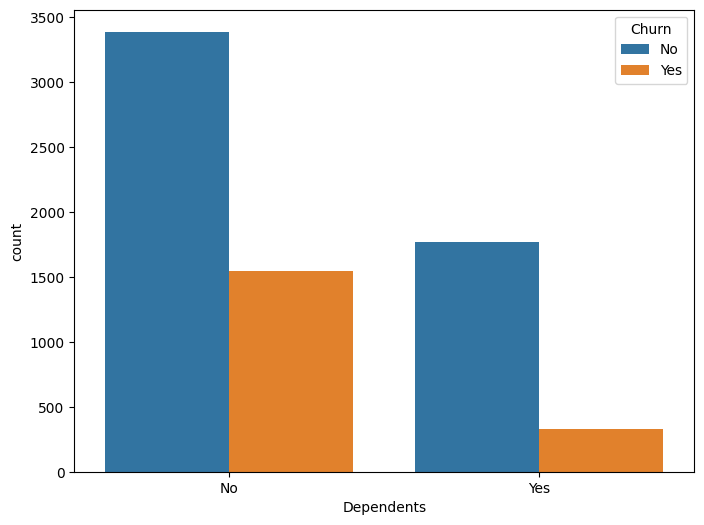

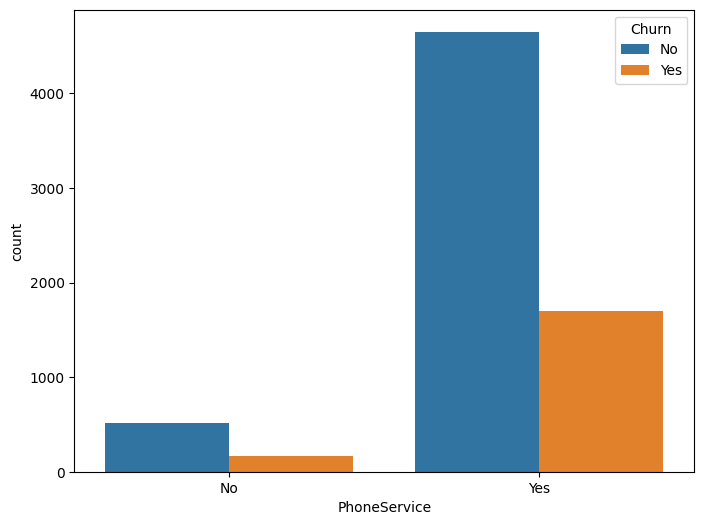

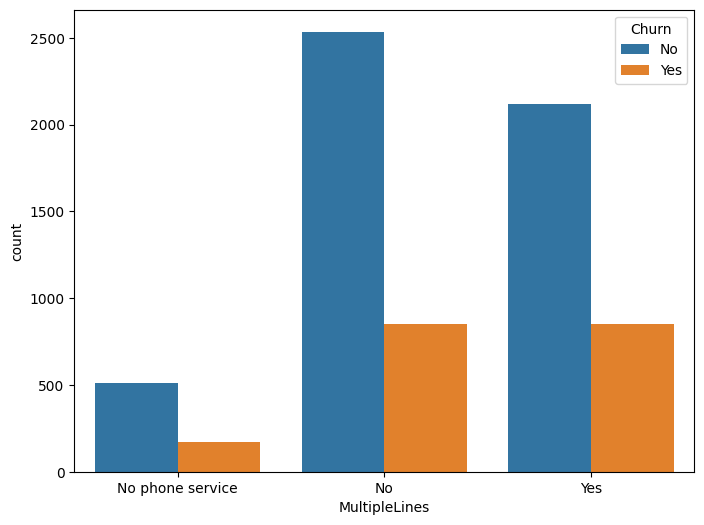

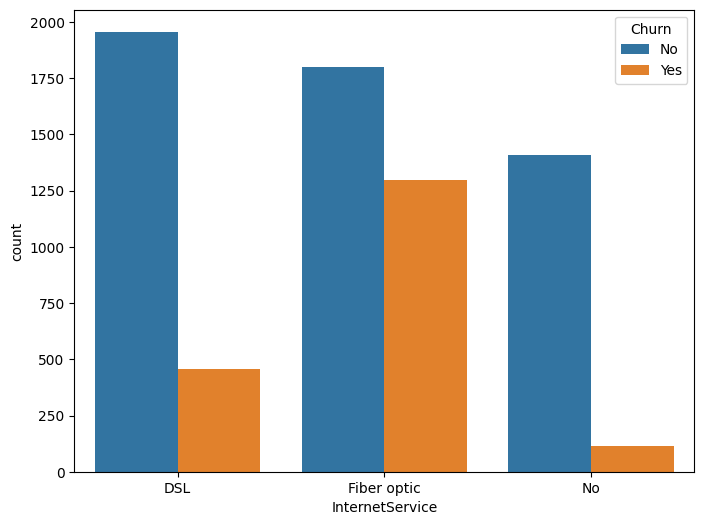

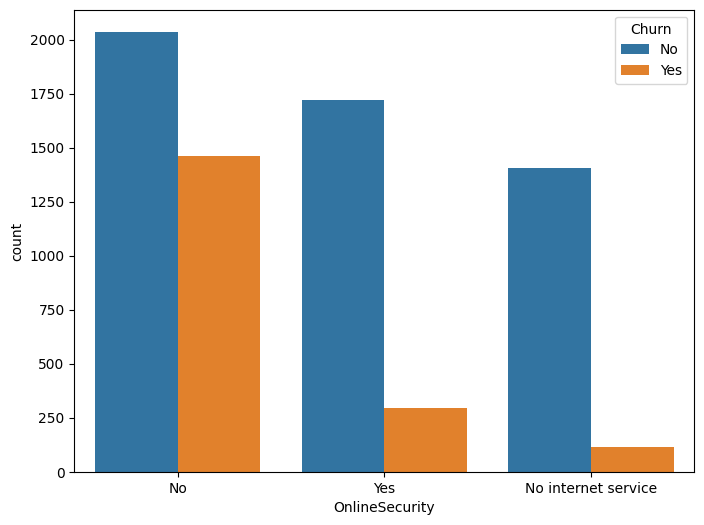

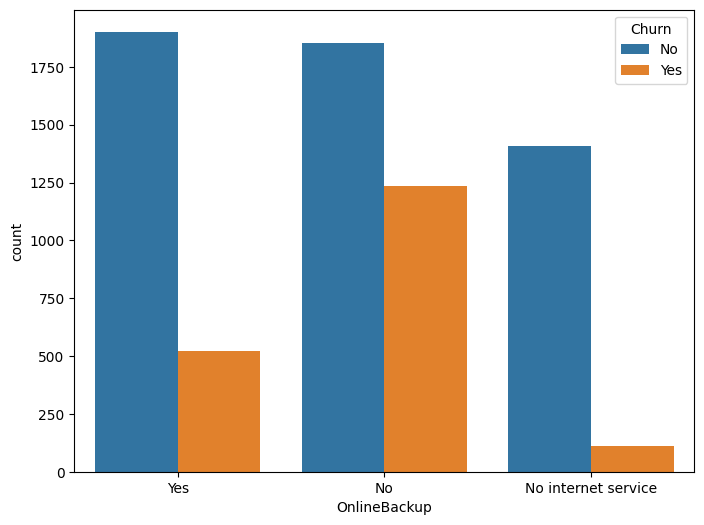

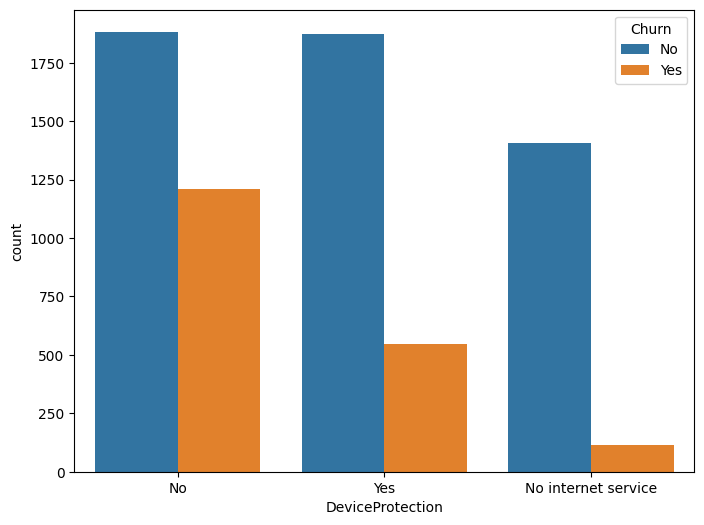

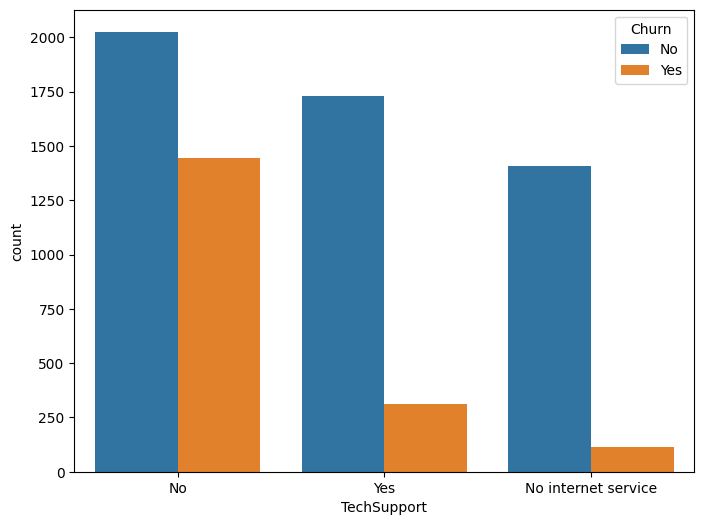

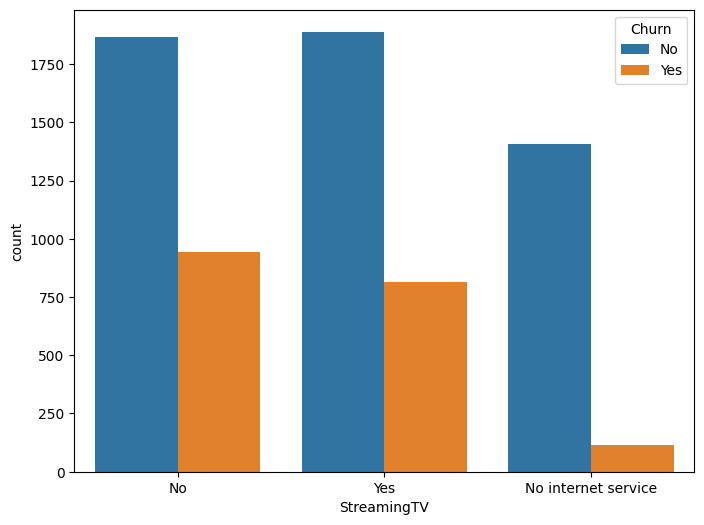

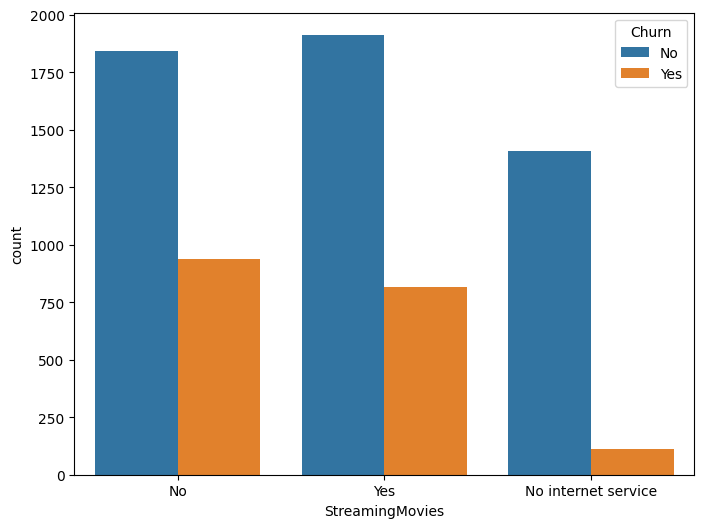

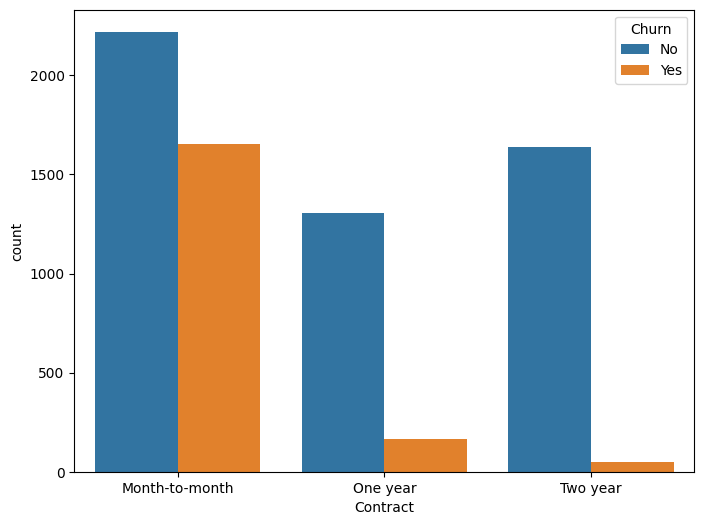

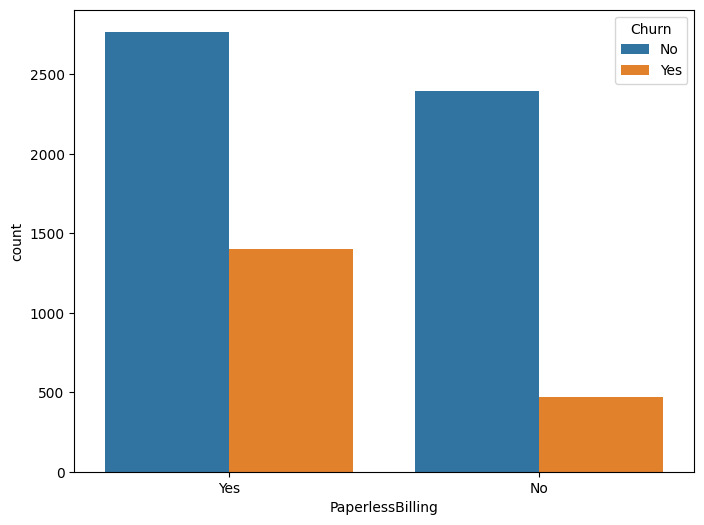

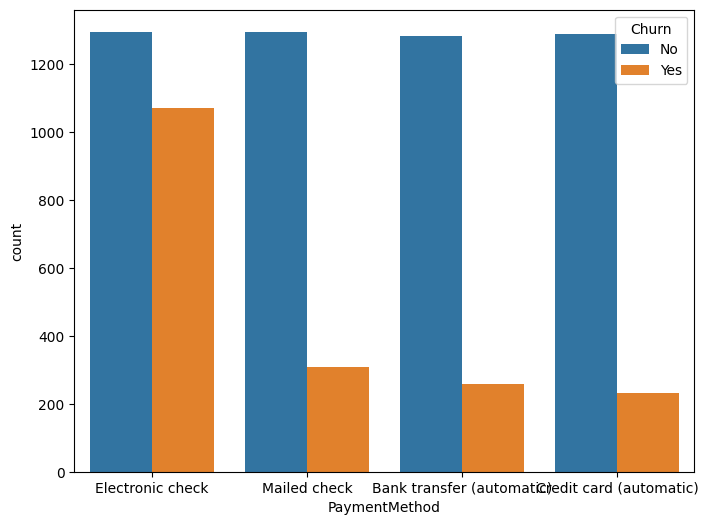

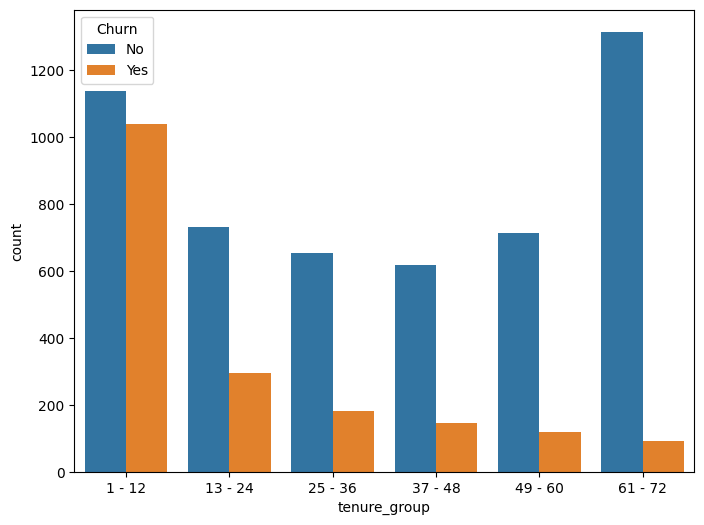

In [27]:
for i, predictor in enumerate(telco_data.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges'])):
    plt.figure(i,figsize=(8,6))
    sns.countplot(data=telco_data, x=predictor, hue='Churn')

In [28]:
telco_data['Churn'] = np.where(telco_data.Churn == 'Yes',1,0)

In [29]:
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


In [30]:
telco_data_dummies = pd.get_dummies(telco_data).astype(int)
telco_data_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29,29,0,1,0,0,1,1,0,...,0,0,1,0,1,0,0,0,0,0
1,0,56,1889,0,0,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,0,53,108,1,0,1,1,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,0,42,1840,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70,151,1,1,0,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0


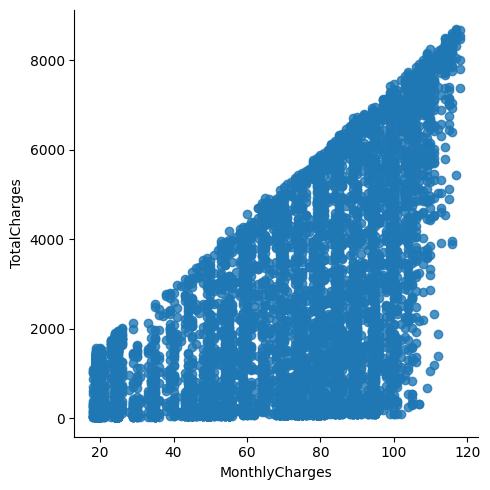

In [31]:
sns.lmplot(data=telco_data_dummies, x='MonthlyCharges', y='TotalCharges', fit_reg=False)

Total Charges increase as Monthly Charges increase - as expected.

**10. ** Churn by Monthly Charges and Total Charges

/tmp/ipykernel_26752/722082952.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 0) ],
/tmp/ipykernel_26752/722082952.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 1) ],


Text(0.5, 1.0, 'Monthly charges by churn')

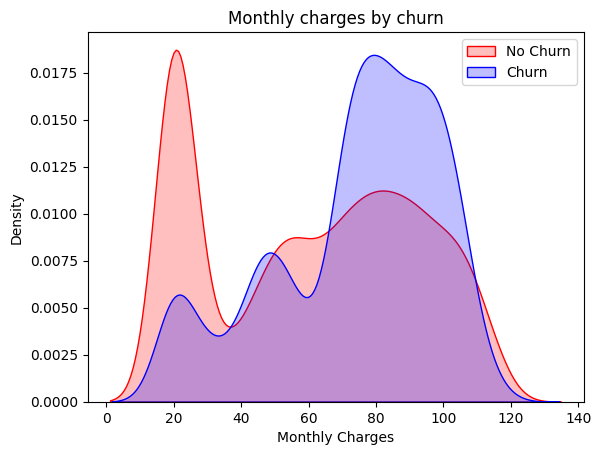

In [32]:
Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 0) ],
                color="Red", shade = True)
Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 1) ],
                ax =Mth, color="Blue", shade= True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly charges by churn')

Insight: Churn is high when Monthly Charges ar high

/tmp/ipykernel_26752/4019118049.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 0) ],
/tmp/ipykernel_26752/4019118049.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 1) ],


Text(0.5, 1.0, 'Total charges by churn')

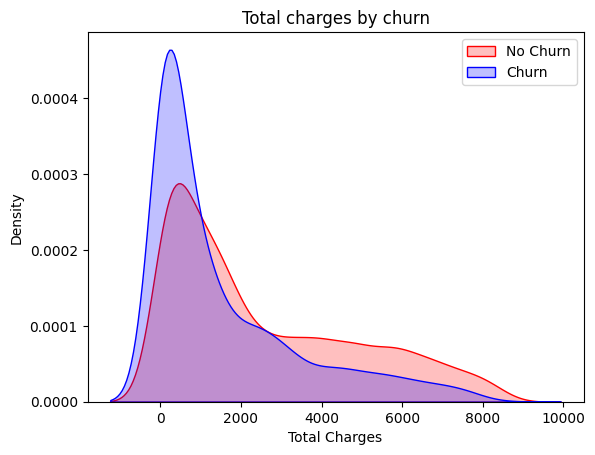

In [33]:
Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 0) ],
                color="Red", shade = True)
Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 1) ],
                ax =Tot, color="Blue", shade= True)
Tot.legend(["No Churn","Churn"],loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Total Charges')
Tot.set_title('Total charges by churn')

In [34]:
telco_data_dummies = pd.get_dummies(telco_data)

*Surprising insight ** as higher Churn at lower Total Charges

However if we combine the insights of 3 parameters i.e. Tenure, Monthly Charges & Total Charges then the picture is bit clear :- Higher Monthly Charge at lower tenure results into lower Total Charge. Hence, all these 3 factors viz Higher Monthly Charge, Lower tenure and Lower Total Charge are linkd to High Churn.

**11. Build a corelation of all predictors with 'Churn' **

<Axes: >

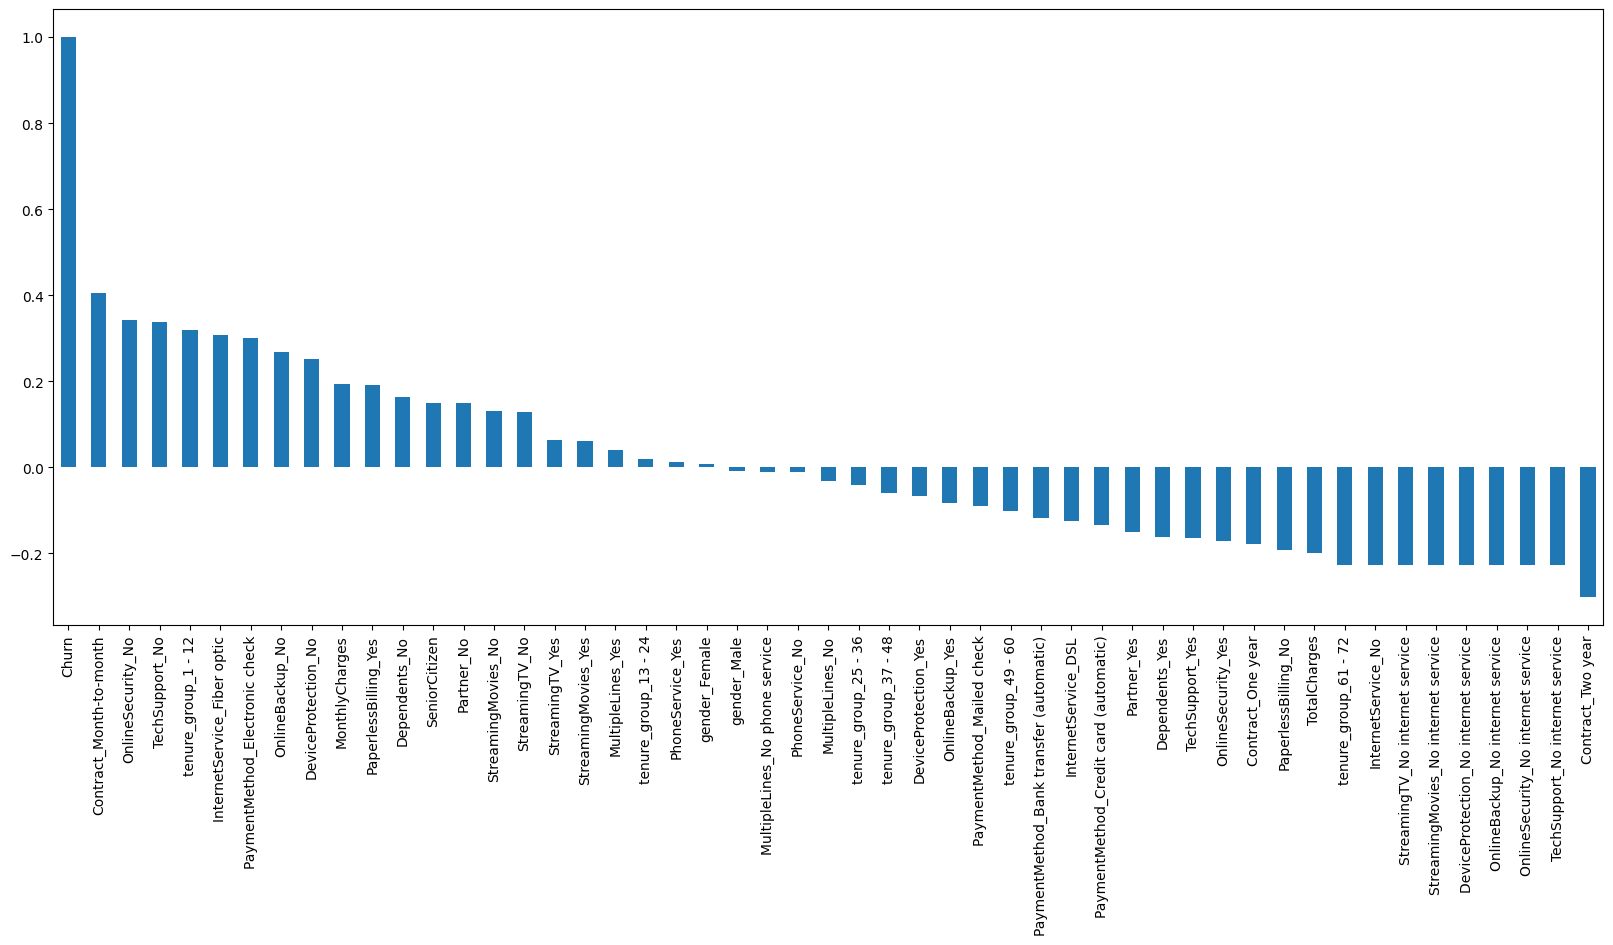

In [35]:
plt.figure(figsize=(20,8))
telco_data_dummies.corr()['Churn'].sort_values(ascending = False).plot(kind='bar')

**Derived Insight: **

HIGH Churn seen in case of Month to month contracts, No online security, No Tech support, First year of subscription and Fibre Optics Internet

LOW Churn is seens in case of Long term contracts, Subscriptions without internet service and The customers engaged for 5+ years

Factors like Gender, Availability of PhoneService and # of multiple lines have alomost NO impact on Churn

This is also evident from the Heatmap below

<Axes: >

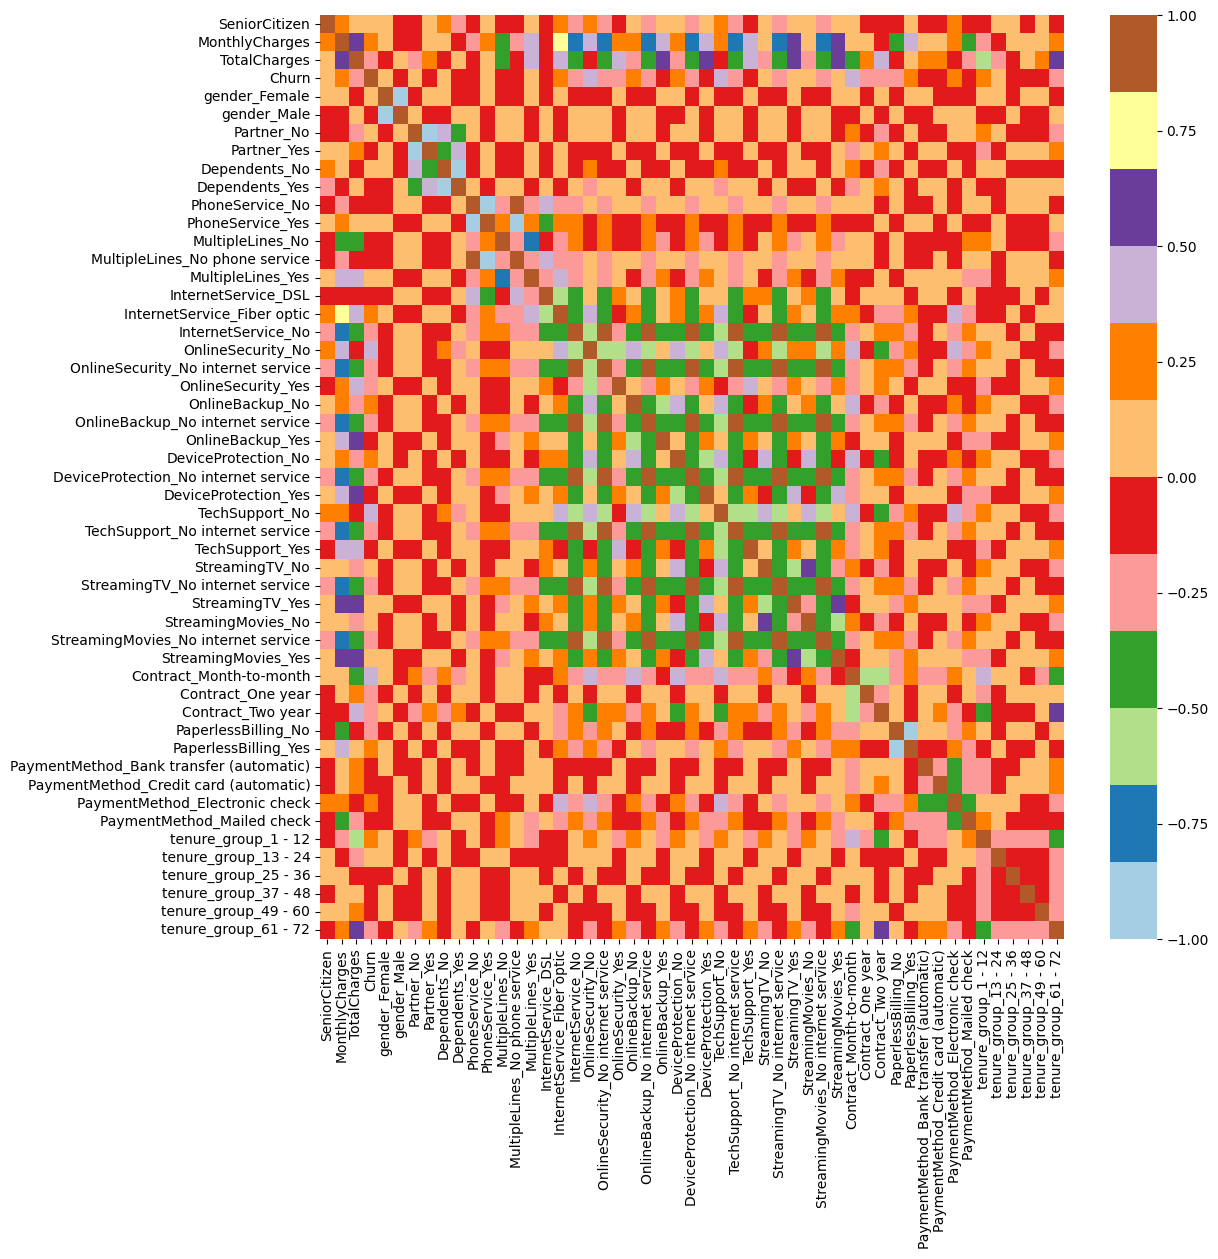

In [36]:
plt.figure(figsize=(12,12))
sns.heatmap(telco_data_dummies.corr(), cmap="Paired")

In [37]:
telco_data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'tenure_group'],
      dtype='object')

Bivariate Analysis

In [38]:
new_df1_target0=telco_data.loc[telco_data["Churn"]==0]
new_df1_target1=telco_data.loc[telco_data["Churn"]==1]

In [39]:
def uniplot(df,col,title,hue =None):

    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30


    temp = pd.Series(data = hue)
    fig, ax = plt.subplots()
    width = len(df[col].unique()) + 7 + 4*len(temp.unique())
    fig.set_size_inches(width , 8)
    plt.xticks(rotation=45)
    plt.yscale('log')
    plt.title(title)
    ax = sns.countplot(data = df, x= col, order=df[col].value_counts().index,hue = hue,palette='bright')

    plt.show()

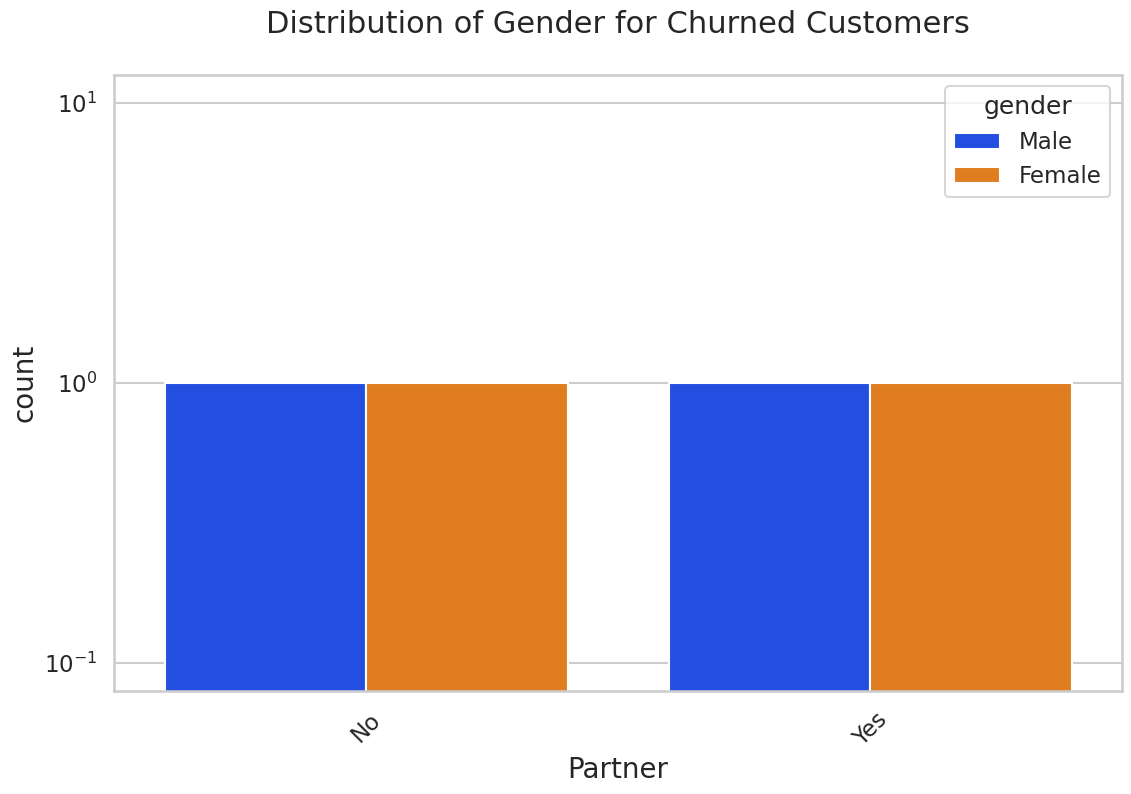

In [40]:
uniplot(new_df1_target1,col='Partner',title='Distribution of Gender for Churned Customers',hue='gender')


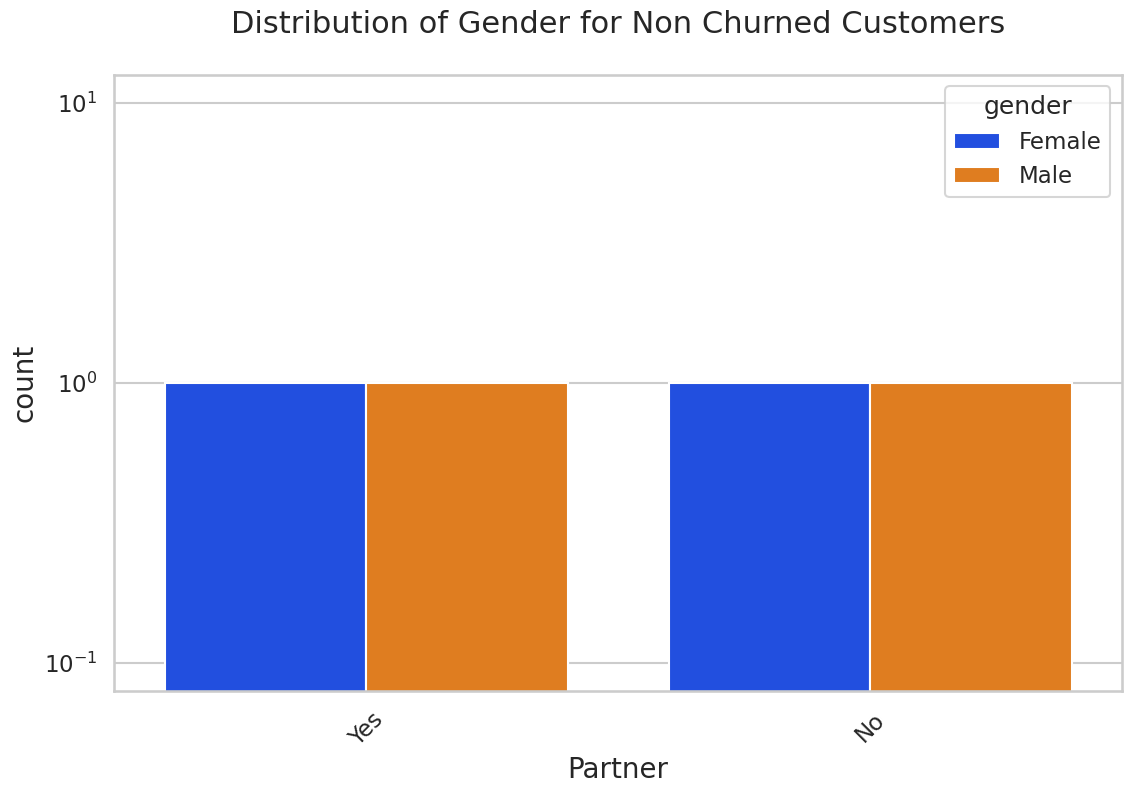

In [41]:
uniplot(new_df1_target0,col='Partner',title='Distribution of Gender for Non Churned Customers',hue='gender')

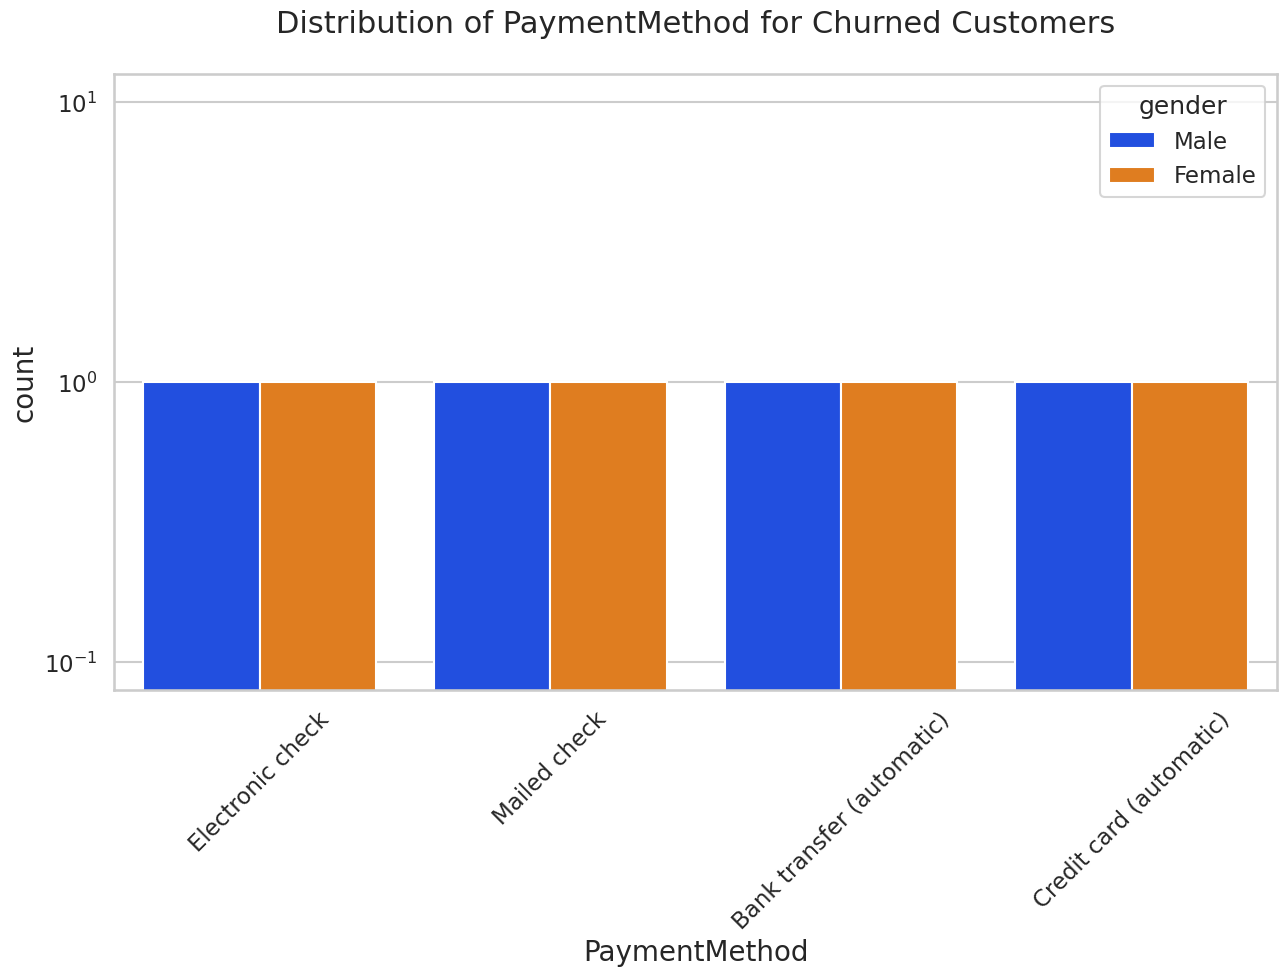

In [42]:
uniplot(new_df1_target1,col='PaymentMethod',title='Distribution of PaymentMethod for Churned Customers',hue='gender')

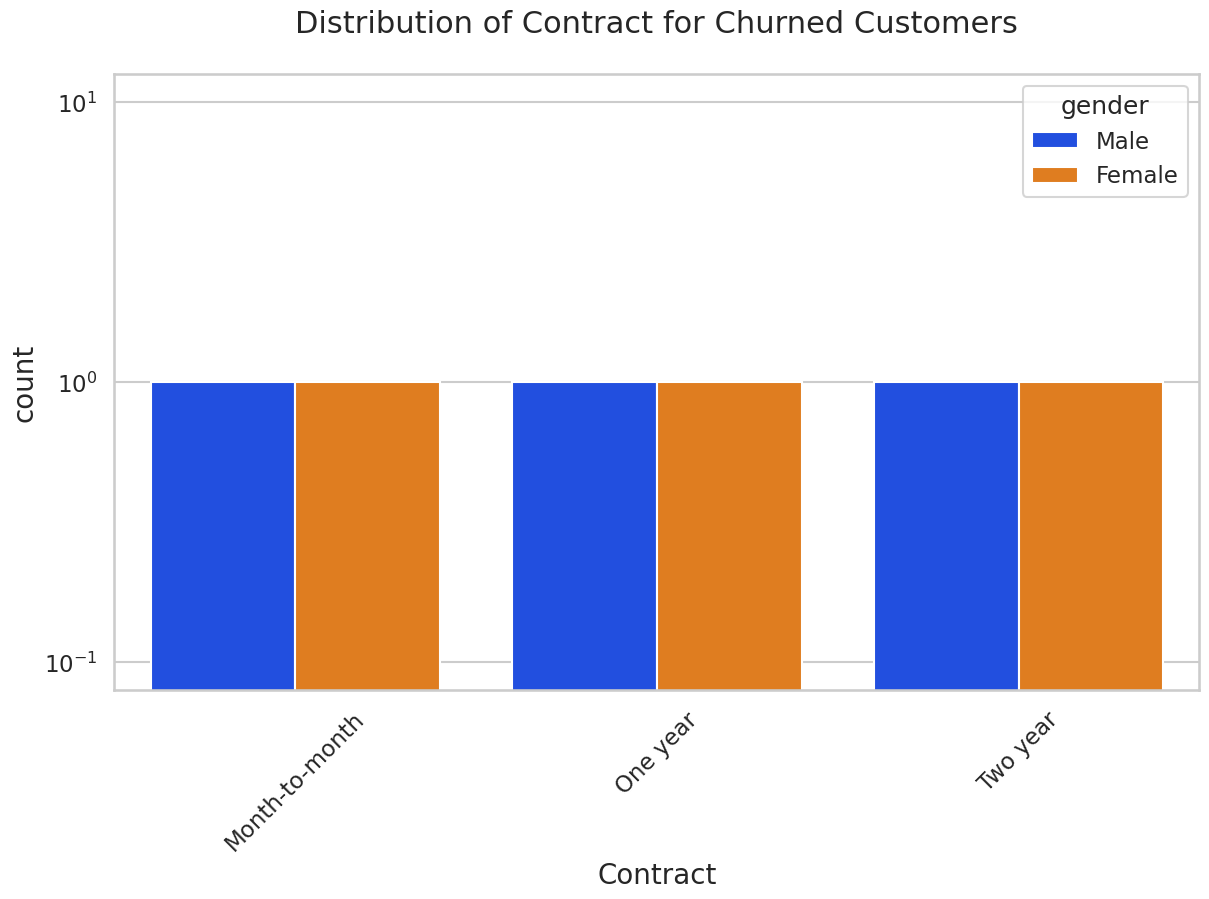

In [43]:
uniplot(new_df1_target1,col='Contract',title='Distribution of Contract for Churned Customers',hue='gender')

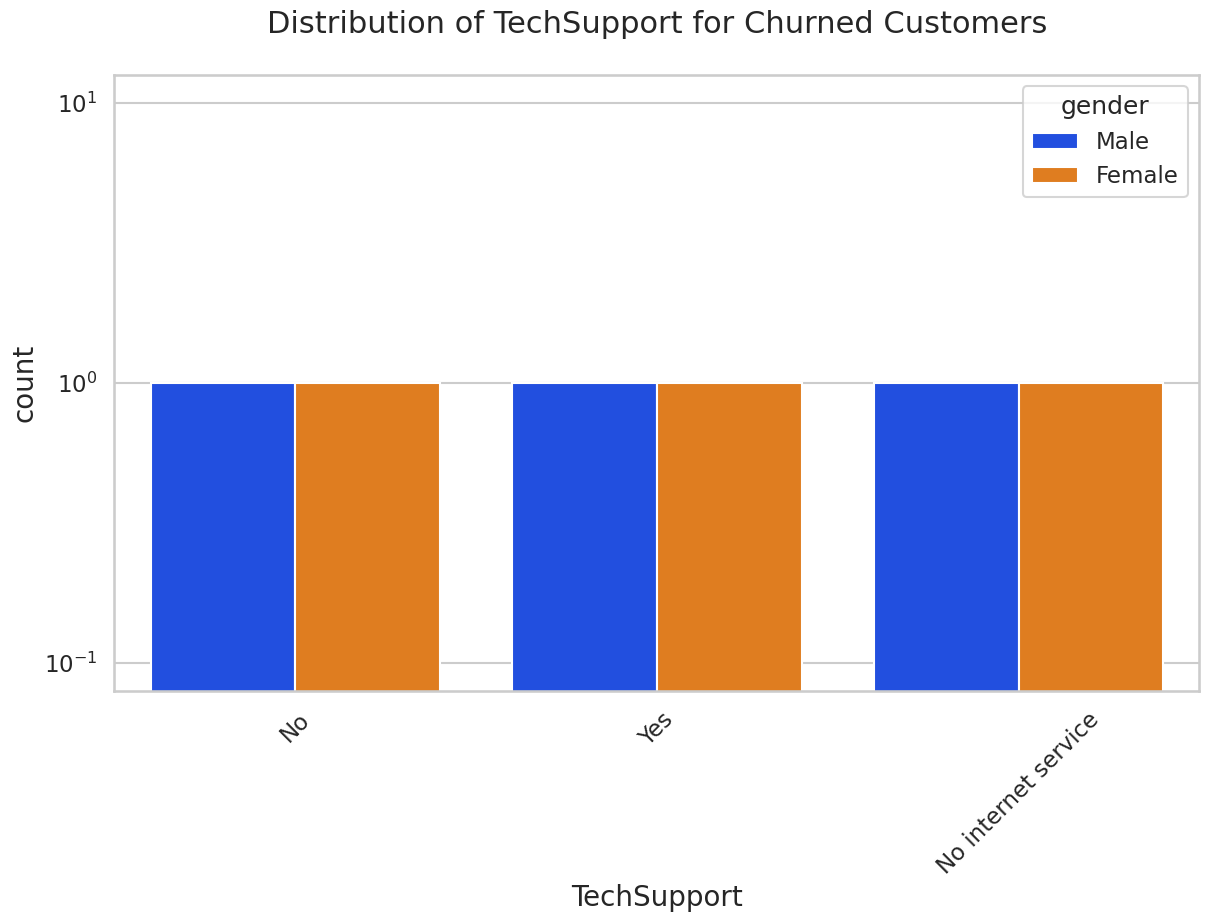

In [44]:
uniplot(new_df1_target1,col='TechSupport',title='Distribution of TechSupport for Churned Customers',hue='gender')

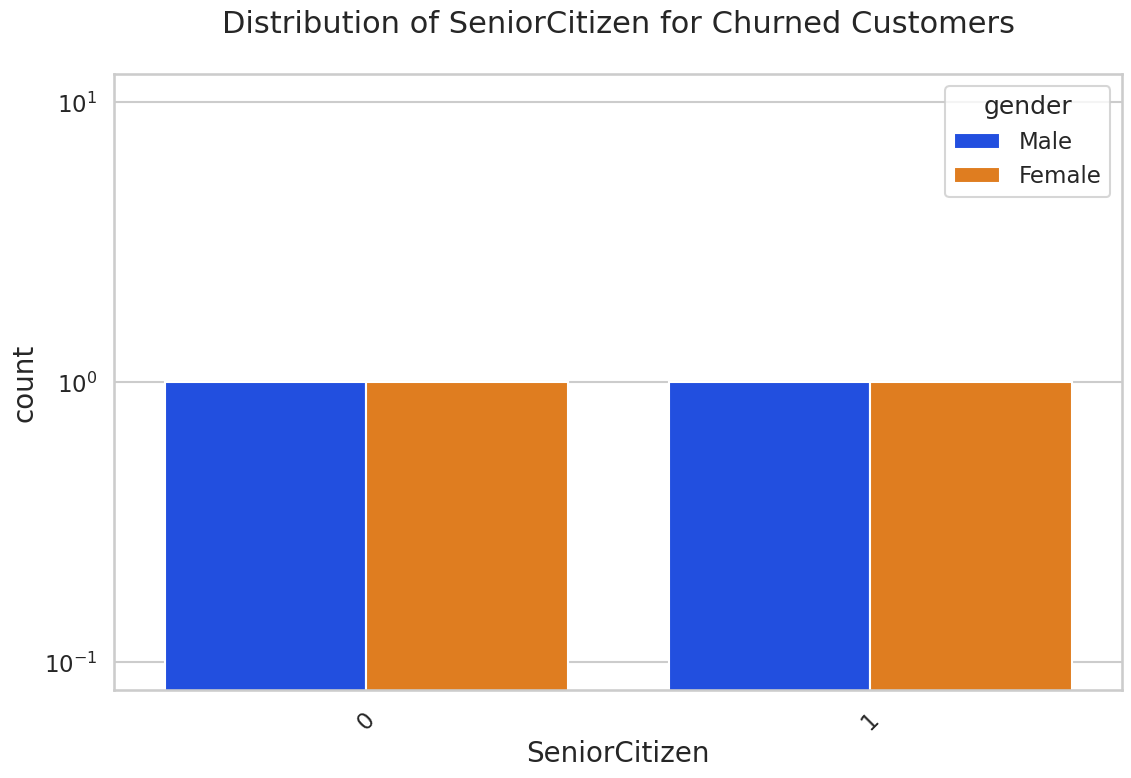

In [45]:
uniplot(new_df1_target1,col='SeniorCitizen',title='Distribution of SeniorCitizen for Churned Customers',hue='gender')

**CONCLUSION**
These are some of the quick insights from this exercise:

Electronic check medium are the highest churners
Contract Type - Monthly customers are more likely to churn because of no contract terms, as they are free to go customers.
No Online security, No Tech Support category are high churners
Non senior Citizens are high churners
Note: There could be many more such insights, so take this as an assignment and try to get more insights :)








In [46]:
telco_data_dummies.to_csv('IBM_Client_Churn_Analysis_Staging.csv')

In [48]:
timestamp = datetime.now()
time_stamp = timestamp.strftime("%Y-%m-%d %H:%M")
bucket = "ibm-internship-major-staging"
S3_PREFIX = f"ibm_internship_major/staging/{time_stamp}"
file_name = "IBM_Client_Churn_Analysis_Staging"
S3_KEY = S3_PREFIX+file_name

timestamp = datetime.now()
time_stamp = timestamp.strftime("%Y-%m-%d_%H-%M")

bucket = "ibm-internship-major-staging"
S3_PREFIX = f"ibm_internship_major/staging/{time_stamp}/"
file_name = "IBM_Client_Churn_Analysis_Staging.csv"

S3_KEY = S3_PREFIX + file_name


try:
    output = BytesIO()
    telco_data_dummies.to_csv(output, index=False)
    output.seek(0)
    s3.upload_fileobj(output, bucket, S3_KEY)
    print(f"Successfully uploaded to: s3://{bucket}/{S3_KEY}")
except Exception as e:
    print(f"Failed to upload: {e}")





response = s3.list_objects_v2(Bucket=bucket, Prefix=S3_PREFIX)

found_key = None

if 'Contents' in response:
    print("Files found:\n")
    for obj in response['Contents']:
        print(obj['Key'])
        if "IBM_Client_Churn_Analysis_Staging.csv" in obj['Key']:
            found_key = obj['Key']
            print(f"\n Selected file: {found_key}")
            break
else:
    print("No files found.")

if found_key:
    data = read_from_s3(bucket, found_key,AWS_REGION)
    print("Data loaded successfully!")
else:
    print("File not found.")



timestamp = datetime.now()
time_stamp = timestamp.strftime("%Y-%m-%d_%H-%M")

bucket = "ibm-internship-major-destination"
S3_PREFIX = f"ibm_internship_major/destination/{time_stamp}/"
file_name = "IBM_Client_Churn_Analysis_Destination.csv"

S3_KEY = S3_PREFIX + file_name



try:
    output = BytesIO()
    data.to_csv(output, index=False)
    output.seek(0)
    s3.upload_fileobj(output, bucket, S3_KEY)
    print(f"Successfully uploaded to: s3://{bucket}/{S3_KEY}")
except Exception as e:
    print(f"Failed to upload: {e}")


Successfully uploaded to: s3://ibm-internship-major-staging/ibm_internship_major/staging/2026-08-04_17-12/IBM_Client_Churn_Analysis_Staging.csv
Files found:

ibm_internship_major/staging/2026-08-04_17-12/IBM_Client_Churn_Analysis_Staging.csv

 Selected file: ibm_internship_major/staging/2026-08-04_17-12/IBM_Client_Churn_Analysis_Staging.csv
File Found
Successfully loaded: s3://ibm-internship-major-staging/ibm_internship_major/staging/2026-08-04_17-12/IBM_Client_Churn_Analysis_Staging.csv
Shape: (7032, 51)
Data loaded successfully!
Successfully uploaded to: s3://ibm-internship-major-destination/ibm_internship_major/destination/2026-08-04_17-12/IBM_Client_Churn_Analysis_Destination.csv
